In [1]:
import sys
print(sys.executable)

e:\brain-tumor-classification-segmentation\.venv\Scripts\python.exe


In [2]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout,MaxPool2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from utils.load_datasets import load_classification_dataset
from  utils.paths import build_path



In [4]:
X_train, y_train, X_test, y_test, class_names = load_classification_dataset()

X_train.shape



(5712, 150, 150, 3)

In [5]:
X_test.shape

(1311, 150, 150, 3)

In [6]:
# Normalizing the data
X_train = X_train/255.0
X_test = X_test/255.0


In [7]:
# Splitting 20% of the training data for validation

X_train_, X_val, y_train_, y_val = train_test_split(X_train,y_train, test_size=0.2, random_state=42)


In [8]:
AlexNet = Sequential()

AlexNet.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding="same", input_shape=(150, 150, 3), activation="relu"))

AlexNet.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

AlexNet.add(Conv2D(64, (5, 5), padding="same", activation="relu"))

AlexNet.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

AlexNet.add(Conv2D(128, (3, 3), padding="same", activation="relu"))

AlexNet.add(Conv2D(128, (3, 3), padding="same", activation="relu"))

AlexNet.add(Conv2D(64, (3, 3), padding="same", activation="relu"))

AlexNet.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

AlexNet.add(Flatten())

AlexNet.add(Dense(128, activation="relu"))

AlexNet.add(Dropout(0.3))

AlexNet.add(Dense(64, activation="relu"))

AlexNet.add(Dropout(0.3))

AlexNet.add(Dense(4, activation="softmax"))

e:\brain-tumor-classification-segmentation\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#add  compile

AlexNet.compile(optimizer= 'adam',
                loss=keras.losses.sparse_categorical_crossentropy, 
                metrics=['accuracy']
                )

In [10]:
# Define callbacks for early stopping and model checkpointing

early_stopping = EarlyStopping(monitor='val_loss', patience=10,    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    build_path("checkpoints","classification","alex_best_model.keras" ) ,    
    monitor='val_loss',    
    save_best_only=True
)

In [11]:
# Training the model

history =AlexNet.fit(X_train_,y_train_,epochs= 10, validation_data=(X_val, y_val), batch_size=32,
                 callbacks=[early_stopping, model_checkpoint])

Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 547s 4s/step - accuracy: 0.5918 - loss: 0.9360 - val_accuracy: 0.7690 - val_loss: 0.5858
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 451s 3s/step - accuracy: 0.7910 - loss: 0.5531 - val_accuracy: 0.8276 - val_loss: 0.4448
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 682s 4s/step - accuracy: 0.8704 - loss: 0.3935 - val_accuracy: 0.8609 - val_loss: 0.3594
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 606s 4s/step - accuracy: 0.8860 - loss: 0.3350 - val_accuracy: 0.8933 - val_loss: 0.2818
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 483s 3s/step - accuracy: 0.9138 - loss: 0.2539 - val_accuracy: 0.9143 - val_loss: 0.2360
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 545s 4s/step - accuracy: 0.9254 - loss: 0.2099 - val_accuracy: 0.9143 - val_loss: 0.2340
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 560s 4s/step - accuracy: 0.9317 - loss: 0.1922 - val_accuracy: 0.9169 - val_loss: 0.2314
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 496s 3s/step - accuracy: 0.9374 - loss: 0.1727 - val_accu

36/36 - 23s - 632ms/step - accuracy: 0.9169 - loss: 0.2314


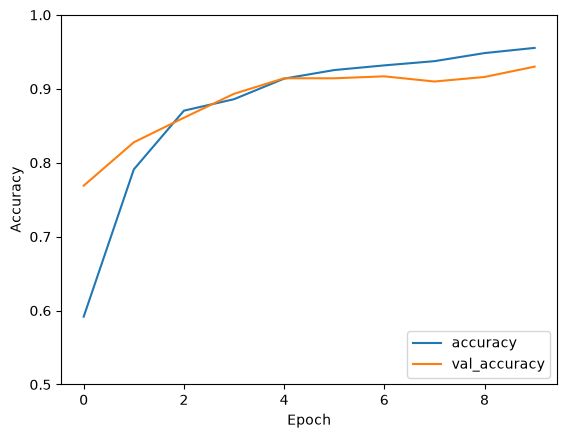

In [12]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = AlexNet.evaluate(X_val,  y_val, verbose=2)